<a href="https://colab.research.google.com/github/Renad110/IT326/blob/main/Reports/phase2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import MinMaxScaler
url = "https://raw.githubusercontent.com/Renad110/IT326/refs/heads/main/Dataset/Raw_dataset/bank-additional-full.csv"
df = pd.read_csv(url, sep=';')
raw_df = df.copy()


🔹 Statistical & Data Overview Analysis:
In this section, we explore the dataset by showing its structure, statistical summary, missing values, and outliers. This helps us understand data quality and what preprocessing might be needed later.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

The dataset contains 41188 rows and 21 columns.  
Most of the attributes are either categorical or numeric,  
which means both types of analysis will be needed.

In [ ]:
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


The table above provides a five-number summary and basic statistics for the numerical columns.
For example, we can see that the average of most numerical attributes, such as `age` and `duration`,
shows moderate variation between the minimum and maximum values, which helps identify data spread and potential outliers.


In [ ]:
missing_values = df.isna().sum()
print("Missing values in each column:")
print(missing_values)

Missing values in each column:
age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64


Missing Values Analysis:
We checked for missing values in each column. The output shows that all columns have zero missing values,
which means the dataset is complete and no imputation is required at this stage.


In [ ]:
from scipy.stats import zscore
# sample dataset
data = df['age']

z_scores = zscore(data)
threshold = 2

outliers = data[abs(z_scores) > threshold]
print("Outliers:", outliers)


Outliers: 8645     61
15798    19
24110    18
27713    70
27715    61
         ..
41174    62
41178    62
41179    64
41183    73
41187    74
Name: age, Length: 985, dtype: int64


Outliers Detection: We used the Z-Score method on the age column to detect unusual values.
This method can also be applied to other numeric columns to find outliers.
The detected extreme values will be handled later during preprocessing.

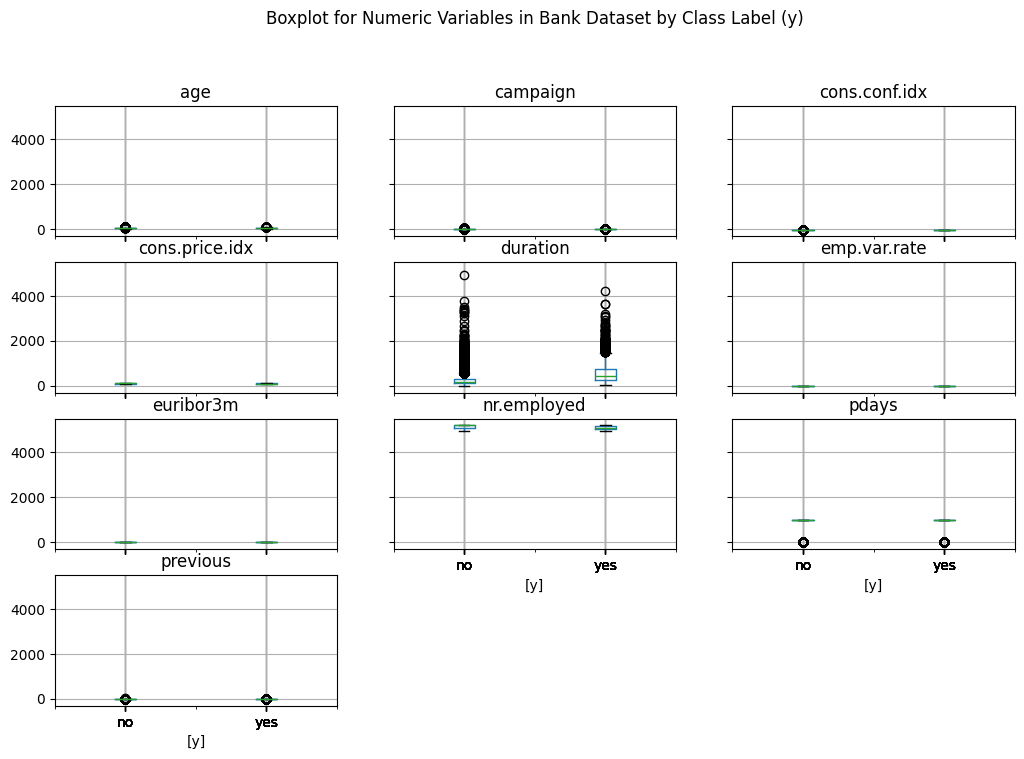

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
url = "https://raw.githubusercontent.com/Renad110/IT326/refs/heads/main/Dataset/Raw_dataset/bank-additional-full.csv"
df = pd.read_csv(url, sep=';')
df.boxplot(by='y', figsize=(12, 8))
plt.suptitle('Boxplot for Numeric Variables in Bank Dataset by Class Label (y)', y=1.02)
plt.show()

The boxplot shows the distribution of numeric variables in the dataset, grouped by the target variable (y).
It helps identify outliers and compare how values differ between the “yes” and “no” classes.
For example, the “duration” variable shows more spread and outliers, which indicates it may strongly influence the model during training.

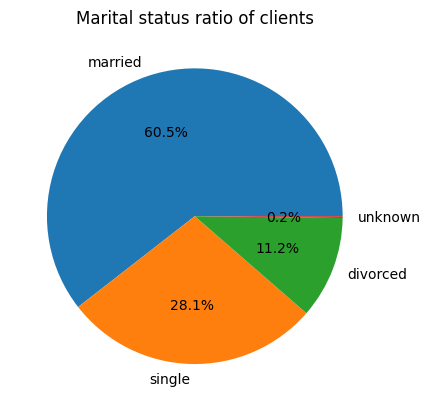

In [ ]:
import matplotlib.pyplot as plt
df["marital"].value_counts().plot(kind="pie", autopct="%.1f%%", title="Marital status ratio of clients")
plt.ylabel("")
plt.show()

The pie chart shows that most clients are married, followed by single and divorced groups. It reveals a class imbalance leaning toward a specific social category. During preprocessing, this helps handle class bias or merge minor groups to maintain balanced data before encoding.

 This insight can later support feature selection by testing whether marital status significantly influences the subscription outcome.

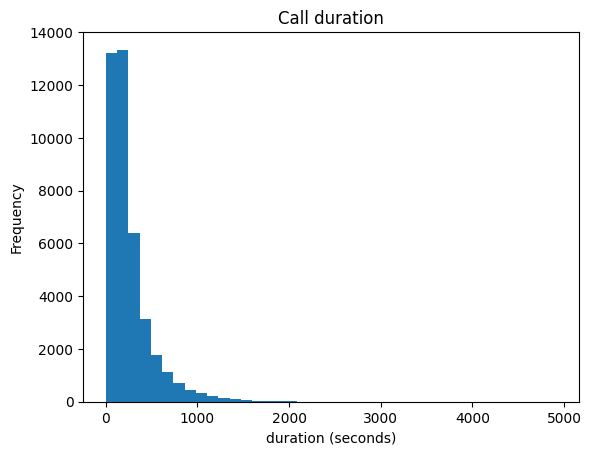

In [ ]:
df["duration"].plot(kind="hist", bins=40, title="Call duration")
plt.xlabel("duration (seconds)")
plt.ylabel("Frequency")
plt.show()


The histogram shows the distribution of call durations, where most calls are short and few are long. It highlights large variation and potential outliers, which helps in preprocessing by applying normalization or removing extreme values to improve data quality.

It can later help determine whether call duration is a key predictive feature affecting client responses to campaigns.

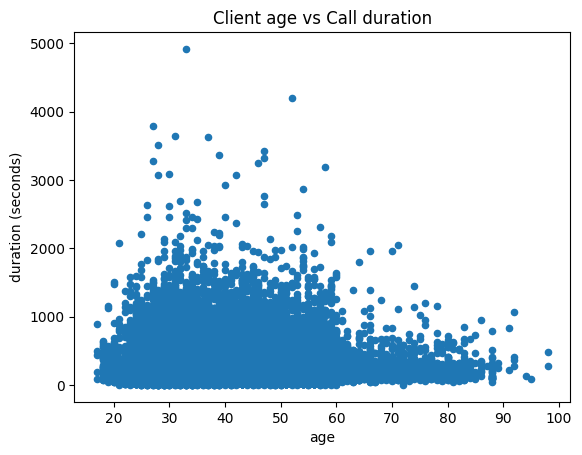

In [ ]:
df.plot.scatter(x="age", y="duration", title="Client age vs Call duration")
plt.xlabel("age")
plt.ylabel("duration (seconds)")
plt.show()


The scatter plot shows the relationship between client age and call duration. It suggests that age has little effect on call length, which helps in preprocessing by analyzing feature correlation and deciding on normalization or feature selection.

This relationship can help evaluate whether age is a meaningful factor for understanding customer behavior or can be excluded.

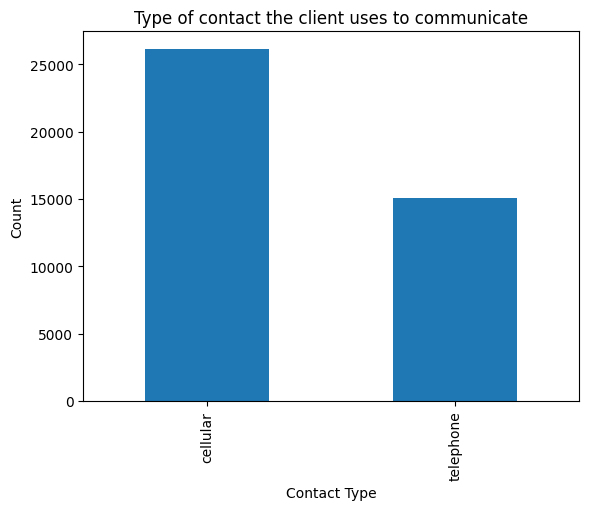

In [ ]:
df['contact'].value_counts().plot(kind='bar', title='Type of contact the client uses to communicate')
plt.xlabel('Contact Type')
plt.ylabel('Count')
plt.show()


The bar chart shows that most clients were contacted via cellular phones rather than landlines, indicating the bank’s reliance on modern communication channels. This insight helps in preprocessing by applying categorical encoding and ensuring class balance.

this feature can be analyzed to see whether the contact method significantly affects client response or not.

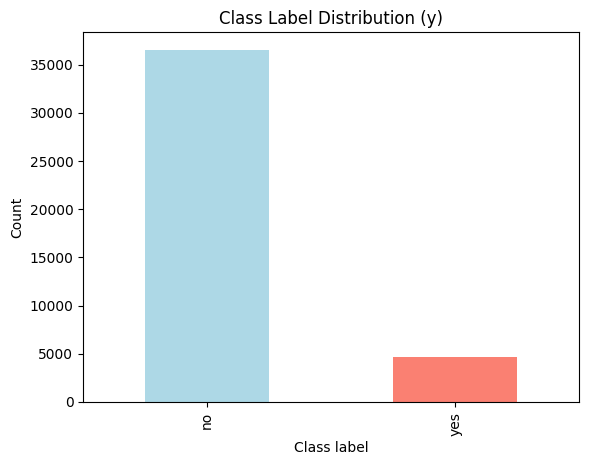

In [ ]:
import matplotlib.pyplot as plt
df['y'].value_counts().plot(kind='bar', color=['lightblue', 'salmon'])
plt.title('Class Label Distribution (y)')
plt.xlabel('Class label')
plt.ylabel('Count')
plt.show()


Class Label Distribution: The bar plot shows the number of samples for each class in the target variable (y).
The dataset is imbalanced, with significantly more “no” responses than “yes.”
This imbalance should be considered during preprocessing or model training to ensure fair prediction performance.

In [ ]:
# 1. Noise Removal , Variable Transformation for 'duration'

# Calculate IQR
Q1 = df['duration'].quantile(0.25)
Q3 = df['duration'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR

initial_len = len(df)
df = df[(df['duration'] <= upper_bound)].copy()

df['log_duration'] = np.log1p(df['duration'])

print(f"Cleaned 'duration' column. Initial rows: {initial_len}, Remaining rows: {len(df)}")


# Discretization for 'age'

bins = [17, 30, 45, 60, 100]
labels = ['Youth (18-29)', 'Adult (30-44)', 'Middle Age (45-59)', 'Senior (60+)']

df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels, right=False)

print("Successfully created 'age_group' column through Discretization.")


# Normalize numeric columns
scaler = MinMaxScaler()
numeric_cols = ['age', 'duration', 'campaign', 'pdays', 'previous',
    'emp.var.rate', 'cons.price.idx', 'cons.conf.idx',
    'euribor3m', 'nr.employed', 'log_duration']
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

print("Numeric columns normalized successfully.")

print("- Before Preprocessing:")
display(raw_df.head())

print("- After Preprocessing:")
display(df.head())



Cleaned 'duration' column. Initial rows: 41188, Remaining rows: 38225
Successfully created 'age_group' column through Discretization.
Numeric columns normalized successfully.
- Before Preprocessing:


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


- After Preprocessing:


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,log_duration,age_group
0,0.481481,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,0.0,nonexistent,0.9375,0.698753,0.60251,0.957379,0.859735,no,0.860740,Middle Age (45-59)
1,0.493827,services,married,high.school,unknown,no,no,telephone,may,mon,...,0.0,nonexistent,0.9375,0.698753,0.60251,0.957379,0.859735,no,0.774531,Middle Age (45-59)
2,0.246914,services,married,high.school,no,yes,no,telephone,may,mon,...,0.0,nonexistent,0.9375,0.698753,0.60251,0.957379,0.859735,no,0.838575,Adult (30-44)
3,0.283951,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,0.0,nonexistent,0.9375,0.698753,0.60251,0.957379,0.859735,no,0.776578,Adult (30-44)
4,0.481481,services,married,high.school,no,no,yes,telephone,may,mon,...,0.0,nonexistent,0.9375,0.698753,0.60251,0.957379,0.859735,no,0.885744,Middle Age (45-59)


**Data Preprocessing Justification**

In this phase, several preprocessing techniques were applied to improve the dataset’s quality and prepare it for the data mining phase. The applied techniques include Noise Removal, Variable Transformation, Discretization, and Normalization.

**Noise Removal** (Outlier Handling)

Why: Outliers in the duration column can negatively affect the analysis and model performance since they distort the scale of the data and bias statistical measures.

How: The Interquartile Range (IQR) method was used to identify and remove extreme values above the upper bound (Q3 + 1.5*IQR).

On which attribute: duration

Improvement: Removing outliers reduced data variability and made the distribution more consistent, which helps classification and clustering algorithms perform more accurately.

**Variable Transformation** (Log Transformation)

Why: The duration attribute had a highly skewed distribution. Log transformation was used to reduce skewness and make the data more normally distributed.

How: A new column log_duration was created using the transformation log1p(duration).

On which attribute: duration

Improvement: The transformation reduced the impact of large values, allowing algorithms like Decision Trees and K-Means to treat all samples more equally.

**Discretization** (Binning)

Why: Continuous numerical data in the age attribute was converted into categorical age groups to simplify interpretation and improve model interpretability.

How: The age column was divided into four bins.

On which attribute: age

Improvement: This technique made the data more understandable and suitable for classification algorithms that can benefit from categorical features.

**Normalization** (Min–Max Scaling)

Why: The numeric attributes had different scales (e.g., age, duration, etc.), which can bias distance-based algorithms such as K-Means.

How: The Min–Max Scaler from sklearn was applied to rescale all numeric features into the range [0, 1].

On which attributes: Numeric attributes.

Improvement: Scaling unified the range of values across features, ensuring that all attributes contribute equally to the learning process.

**Summary of Results**

After preprocessing, the dataset became cleaner, more balanced, and more suitable for machine learning tasks.
Outliers were removed, distributions were smoothed, and numeric attributes were scaled consistently.

In [ ]:
# Save the preprocessed dataset
df.to_csv('Preprocessed_dataset.csv', index=False)